In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, QTable
from astropy.visualization import quantity_support
quantity_support()  


import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [38]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

## Data

### Orion Opacity, Temple SED

In [2]:
Orion_opacity = OpacityData.from_file('data/opacity_law/Orion.opc')
Temple_SED = SED.from_file('data/raw/quasar5.template')
# Temple_SED = SED.from_file('data/raw/quasar5_ly.template')

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


### Labbe photometric data

In [3]:
# 来自 Kohei 给的数据（从图上描下来的）
Labbe_photo_raw = Table.read('data/raw/Labbe_photo.dat', format='ascii', names=['lg_lambda', 'lg_nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': 10**Labbe_photo_raw['lg_lambda'] * u.micron, 
                      'nu_L_nu': 10**Labbe_photo_raw['lg_nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
# Labbe_photo.meta = {'z': 4.4655, }
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

In [4]:
# Setton et al. 2025, Fig 4.a
# A2744-45924
# 政融从图上描下来的。
Labbe_photo_raw = Table.read('data/raw/Setton25.csv', format='ascii', names=['lambda', 'nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': Labbe_photo_raw['lambda'] * u.micron, 
                      'nu_L_nu': Labbe_photo_raw['nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

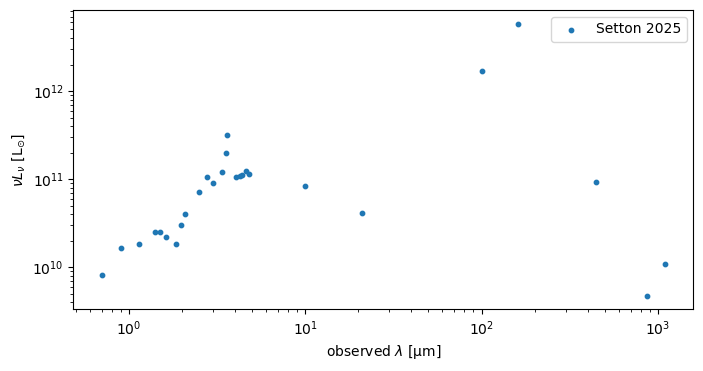

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x='wavelength_obs', y='nu_L_nu', data=Labbe_photo, s=10, label='Setton 2025')
ax.set_xlabel(fr'observed $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
ax.legend()

### Opacity laws from file

In [14]:
opacity_laws = {
    path.stem: OpacityData.from_file(path) 
    for path in Path('data/opacity_law').glob('*.opc')
}

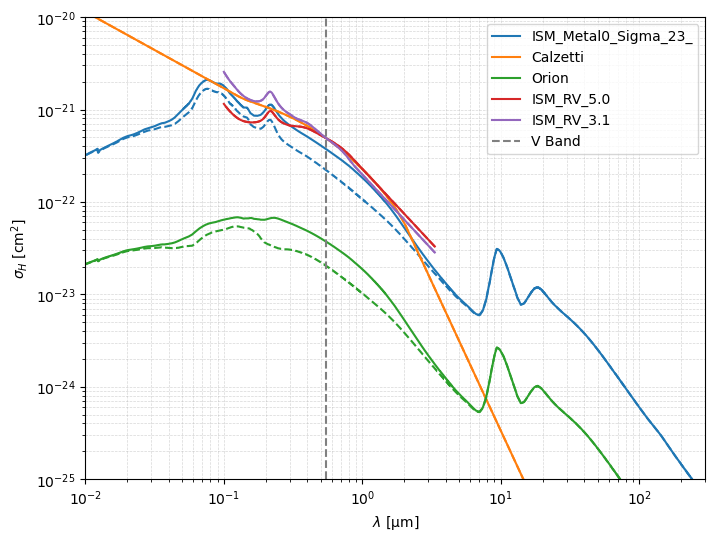

In [82]:
fig, ax = plt.subplots(1, 1, figsize=[8,6], dpi=100)



ax.grid(True, which='both', linestyle='--', linewidth=.5, alpha=.5)

for name, opacity in opacity_laws.items():
    lines = ax.loglog(opacity.wavelength, opacity.sigma_H_ext, label=name[:20], )
    ax.loglog(opacity.wavelength, opacity.sigma_H_abs, linestyle='--', color=lines[0].get_color())
ax.axvline(5470 * u.AA, linestyle='--', color='gray', label='V Band')    

ax.set_xlim(*[1e-2, 3e2]*u.micron)
ax.set_ylim(1e-25*u.cm**2, 1e-20*u.cm**2)
ax.set_xlabel(rf'$\lambda$ [{ax.get_xlabel()}]')
ax.set_ylabel(rf'$\sigma_H$ [{ax.get_ylabel()}]')
ax.legend()

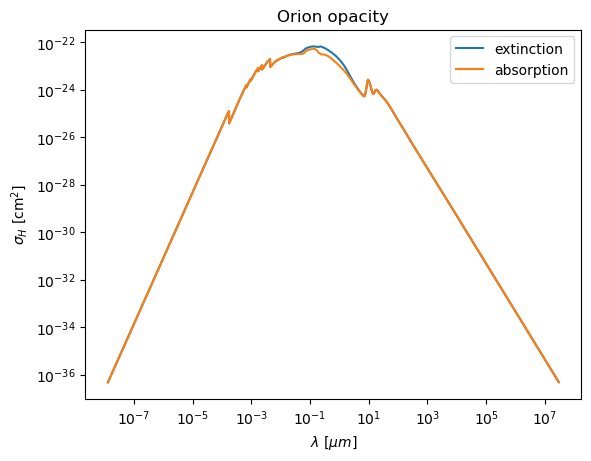

In [6]:
plt.loglog(Orion_opacity.wavelength.to(u.micron), Orion_opacity.sigma_H_ext.to(u.cm**2), label='extinction')
plt.loglog(Orion_opacity.wavelength.to(u.micron), Orion_opacity.sigma_H_abs.to(u.cm**2), label='absorption')
# plt.yscale('linear')
plt.xlabel(rf"$\lambda \ [\mu m] $")
plt.ylabel(rf"$\sigma_H \ [{{\rm cm}}^2]$")
plt.title(rf"Orion opacity")
plt.legend()

### extinction curve

In [70]:
Orion_opacity.sigma_H_ext_V

<Quantity 3.71876811e-23 cm2>

In [9]:
import dust_extinction
import dust_extinction.averages
import dust_extinction.grain_models

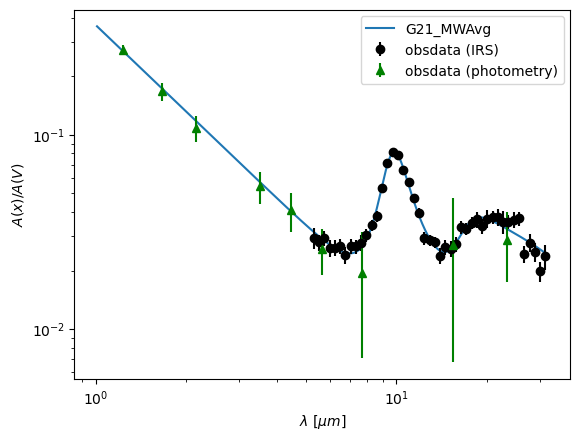

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from dust_extinction.averages import G21_MWAvg

fig, ax = plt.subplots()

# generate the curves and plot them
lam = np.logspace(np.log10(1.01), np.log10(31.9), num=1000)
x = (1.0/lam)/u.micron

# define the extinction model
ext_model = G21_MWAvg()

ax.plot(1.0/x,ext_model(x),label='G21_MWAvg')
ax.errorbar(1.0/ext_model.obsdata_x_irs, ext_model.obsdata_axav_irs,
            yerr=ext_model.obsdata_axav_unc_irs,
            fmt='ko', label='obsdata (IRS)')
ax.errorbar(1.0/ext_model.obsdata_x_bands, ext_model.obsdata_axav_bands,
            yerr=ext_model.obsdata_axav_unc_bands,
            fmt='g^', label='obsdata (photometry)')

ax.set_xlabel(r'$\lambda$ [$\mu m$]')
ax.set_ylabel(r'$A(x)/A(V)$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best')
plt.show()

In [13]:
wavelength = (np.geomspace(1e-2, 1e4, 1000) * u.micron)[::]
with u.set_enabled_equivalencies(u.spectral()):
    
    op = OpacityData(nu=wavelength.to(u.Hz, u.spectral()), 
                sigma_H_ext=ext_model(wavelength) * Orion_opacity.interp_ext(5470 * u.AA,),
                sigma_H_abs=ext_model(wavelength) * Orion_opacity.interp_ext(5470 * u.AA,),
            )

In [14]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=0.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=op, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

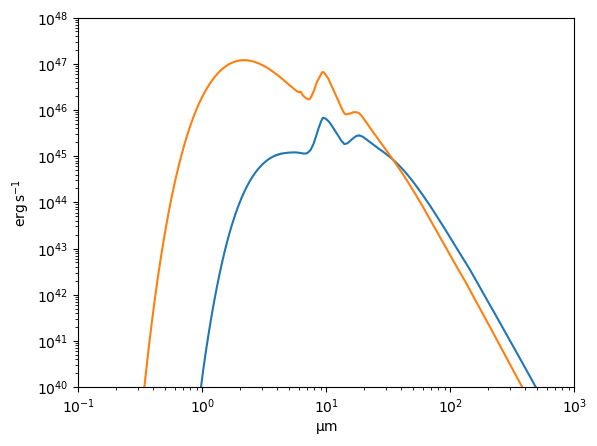

In [15]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu())
plt.xlim(1e-1, 1e3)
plt.ylim(1e40, 1e48)

model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=op, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu())

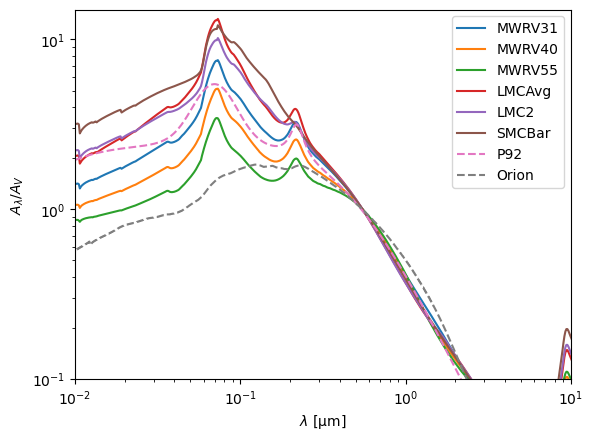

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from dust_extinction.grain_models import WD01
from dust_extinction.shapes import P92

fig, ax = plt.subplots(dpi=100)

tmod = WD01()
possmodels = tmod.possnames.keys()

# generate the curves and plot them
lam = np.geomspace(1e-2, 1e4, num=1000)
x = (1.0 / lam) / u.micron

for cmodel in possmodels:
    # define the extinction model
    ext_model = WD01(cmodel)
    ax.plot(lam,ext_model(x),label=cmodel)
    

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(lam[(1e-3 < lam) & (lam < 1e3)], P92()(lam[(1e-3 < lam) & (lam < 1e3)] * u.micron), label='P92', ls='--')

# ax.autoscale(False)
ax.plot(Orion_opacity.wavelength, Orion_opacity.sigma_H_ext / Orion_opacity.interp_ext((5470 * u.AA).to(u.Hz, u.spectral())), label='Orion', ls='--')

ax.set_xlim(1e-2, 1e1)
ax.set_ylim(1e-1, 15)


ax.set_xlabel(rf'$\lambda$ [{ax.get_xlabel()}]')
ax.set_ylabel(r'$A_\lambda/A_V$')
ax.legend(loc='best')
plt.show()

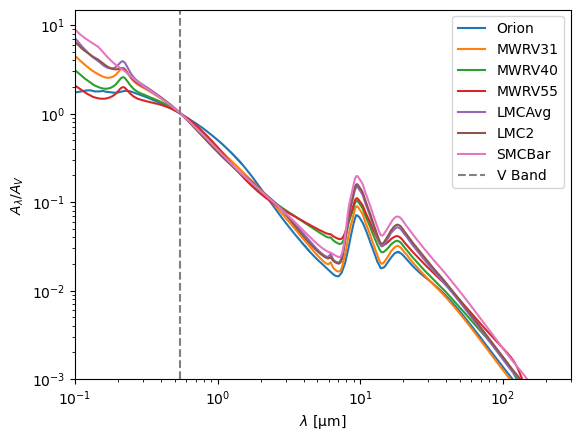

In [113]:
# WD01 系列 

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from dust_extinction.grain_models import WD01

fig, ax = plt.subplots()

model_names = WD01().possnames.keys()

# generate the curves and plot them
lam = np.geomspace(1e-2, 1e4, num=1000) * u.micron

ax.plot(Orion_opacity.wavelength, Orion_opacity.sigma_H_ext / Orion_opacity.sigma_H_ext_V, label='Orion')

for model_name in model_names:
    # define the extinction model
    ext_model = WD01(model_name)
    ax.loglog(lam, ext_model(lam), label=model_name)
    
ax.axvline(5470 * u.AA, linestyle='--', color='gray', label='V Band')    


ax.set_xlim(*[1e-1, 3e2]*u.micron)
ax.set_ylim(1e-3, 15)

ax.set_xlabel(rf'$\lambda$ [{ax.get_xlabel()}]')
ax.set_ylabel(r'$A_\lambda/A_V$')
ax.legend(loc='best')
plt.show()

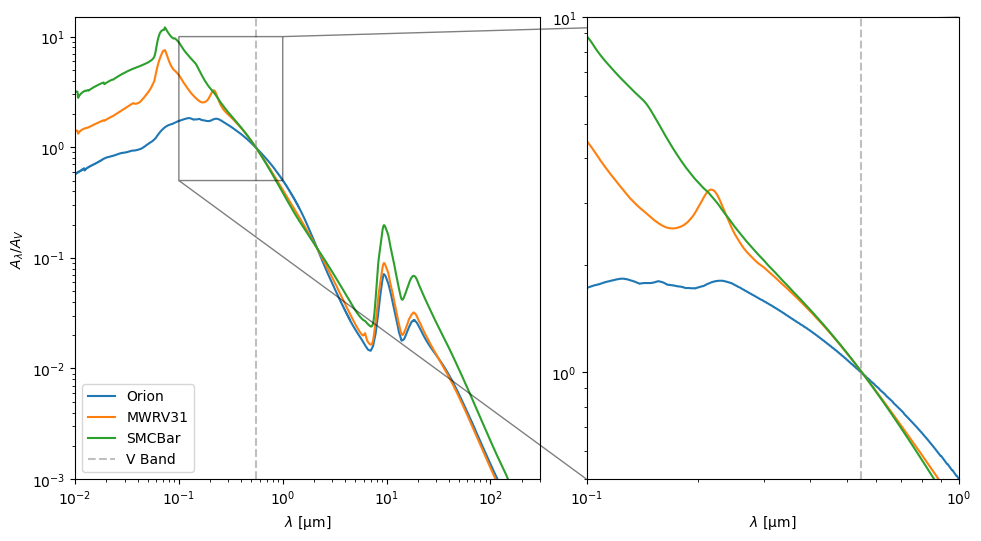

In [8]:
# 只挑选 3 个模型：Orion, ISM, SMC

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from dust_extinction.grain_models import WD01

fig, ax = plt.subplots(figsize=[6,6], dpi=100)

model_names = WD01().possnames.keys()
ax_inset = ax.inset_axes([1.1, 0, .8, 1], xlim=[1e-1, 1e0] * u.micron, ylim=[5e-1, 1e1])

# generate the curves and plot them
lam = np.geomspace(1e-2, 1e4, num=1000) * u.micron

def _plot(ax: plt.Axes):
    ax.loglog(Orion_opacity.wavelength, Orion_opacity.sigma_H_ext / Orion_opacity.sigma_H_ext_V, label='Orion')
    
    for model_name in ['MWRV31', 'SMCBar']:
        # define the extinction model
        ext_model = WD01(model_name)
        ax.loglog(lam, ext_model(lam), label=model_name)
        
    ax.axvline(5470 * u.AA, linestyle='--', color='gray', label='V Band', alpha=0.5)  
     
_plot(ax)
_plot(ax_inset)    


ax.indicate_inset_zoom(ax_inset, edgecolor='k', )

ax_inset.set_xticklabels([], minor=True)

ax.set_xlim(*[1e-2, 3e2]*u.micron)
ax.set_ylim(1e-3, 15)

set_xylabel_with_unit(ax, xlabel=r'$\lambda$', ylabel=r'$A_\lambda/A_V$')
set_xylabel_with_unit(ax_inset, xlabel=r'$\lambda$')
ax.legend(loc='lower left')

In [17]:
P92

<class 'dust_extinction.shapes.P92'>
Name: P92
N_inputs: 1
N_outputs: 1
Fittable parameters: ('BKG_amp', 'BKG_lambda', 'BKG_b', 'BKG_n', 'FUV_amp', 'FUV_lambda', 'FUV_b', 'FUV_n', 'NUV_amp', 'NUV_lambda', 'NUV_b', 'NUV_n', 'SIL1_amp', 'SIL1_lambda', 'SIL1_b', 'SIL1_n', 'SIL2_amp', 'SIL2_lambda', 'SIL2_b', 'SIL2_n', 'FIR_amp', 'FIR_lambda', 'FIR_b', 'FIR_n')

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered

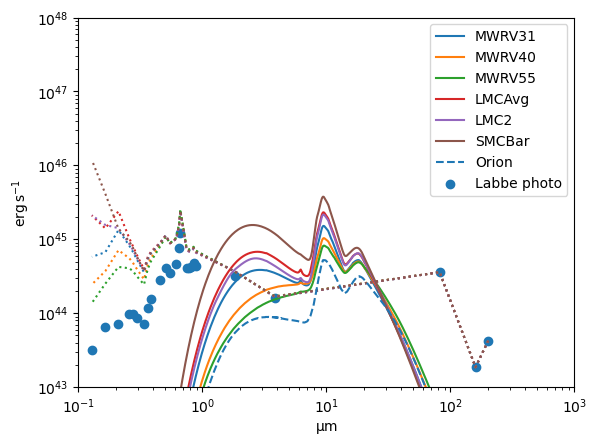

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from dust_extinction.grain_models import WD01
from dust_extinction.shapes import P92

fig, ax = plt.subplots(dpi=100)
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

tmod = WD01()
possmodels = tmod.possnames.keys()

# generate the curves and plot them
lam = np.logspace(-2.0, 4.0, num=1000)
x = (1.0 / lam) / u.micron


for index, cmodel in enumerate(possmodels):
    # define the extinction model
    ext_model = WD01(cmodel)
    op = OpacityData.from_extinction_model(ext_model, sigma_H_V=Orion_sigma_H_V)
    model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=1 * u.mag(), opacity=op, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']), 
                      tau_ph=0) #BUG 目前没有处理 rad press cross section
    ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), label=cmodel, color=color_cycle[index], )
    ax.loglog(model.incident_SED.nu.to(u.um, u.spectral()), model.incident_SED.L_nu * model.incident_SED.nu, color=color_cycle[index], ls=':') #  de-reddened 入射光谱
    
    
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=1 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']), 
                      tau_ph=0)

ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), label='Orion', ls='--')

# ax.scatter()
#TEMP
ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, label='Labbe photo', )


ax.set_xscale('log')
ax.set_yscale('log')


# ax.autoscale(False)

ax.set_xlim(1e-1, 1e3)
ax.set_ylim(1e43, 1e48)

# ax.set_xlim(1e-2, 1e3)
# ax.set_ylim(1e-1, 15)



ax.legend(loc='best')
plt.show()

## Models

In [6]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [1.16758034e+16, 1.18669005e+16, 1.20854291e+16, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / s>

In [ ]:
Orion_opacity = OpacityData.from_file('data/opacity_law/Orion.opc')
Orion_opacity_10 = OpacityData.from_file('data/opacity_law/Orion.opc', factor=1e1)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

(1e+40, 1e+48)

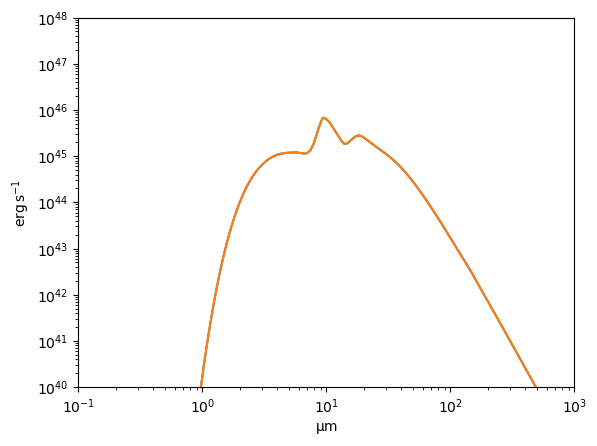

In [27]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu())
plt.xlim(1e-1, 1e3)
plt.ylim(1e40, 1e48)

model = A_V_Model(n_0=1e3/1e1 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity_10, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu())
plt.xlim(1e-1, 1e3)
plt.ylim(1e40, 1e48)

## 临时测试

### 积分用 opacity 的 nu 还是 SED 的？

#### 比较积分收敛性

In [7]:
integrate.trapezoid([1,2,3], [1,2,3])

np.float64(4.0)

In [164]:
list(x_distribution_options)

['linear', 'log']

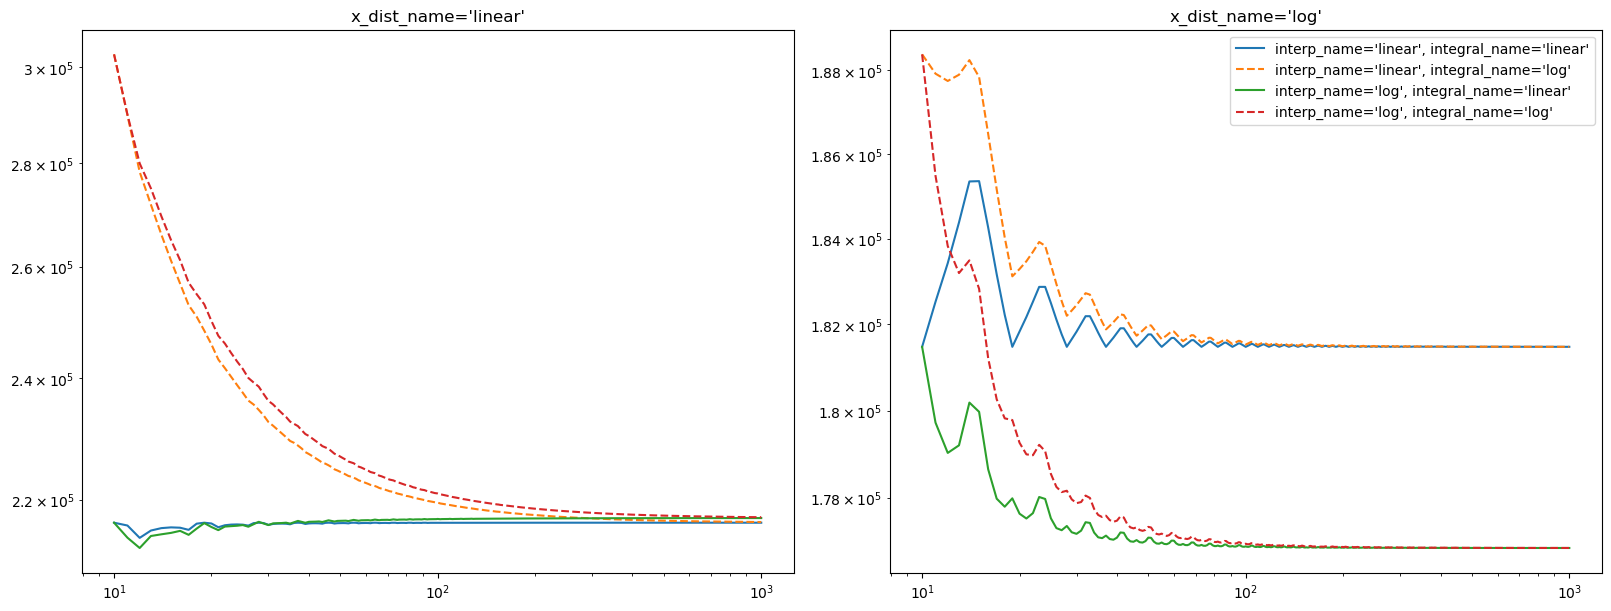

In [248]:
x_distribution_options = {'linear':np.linspace, 'log':np.geomspace}
interp_options = {'linear':LinearInterpolator, 'log':LogLogInterpolator}
integrate_options = {'linear':integrate.trapezoid, 'log':trapz_log}

n_sample_list = np.geomspace(10, 1000, 1000, dtype=int)

fig, axs = plt.subplot_mosaic([list(x_distribution_options)], figsize=(16, 6), layout='constrained')

for x_dist_name, x_dist_func in x_distribution_options.items():
    ax = axs[x_dist_name]
    
    x_min, x_max = 1e1, 1e5
    x_course = x_dist_func(x_min, x_max, 10)
    y_course = np.sin(x_course / 1e4) + 2
    
    x_list = [x_dist_func(x_min, x_max, n_sample) for n_sample in n_sample_list]

    for interp_name, interpolator in interp_options.items():
        interp_func = interpolator(x_course, y_course)
        
        for integral_name, integral_func in integrate_options.items():
            ax.plot(n_sample_list, [integral_func(interp_func(x), x) for x in x_list], 
                    label=f'{interp_name=}, {integral_name=}', ls={'linear': '-', 'log':'--'}[integral_name], )
            

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{x_dist_name=}')

plt.legend()

#### opacity 和 SED 的数据分布

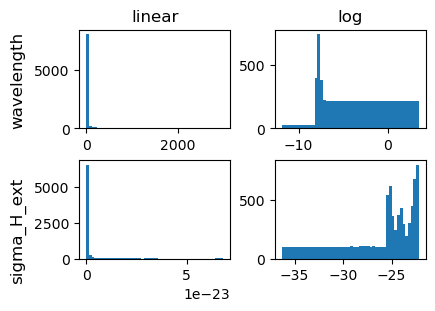

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(4, 3), layout='constrained')
with plt.rc_context(rc={'hist.bins': 50}):
    axs[0, 0].hist(         Orion_opacity.wavelength.cgs.value)
    axs[0, 1].hist(np.log10(Orion_opacity.wavelength.cgs.value))
    axs[1, 0].hist(         Orion_opacity.sigma_H_ext.cgs.value)
    axs[1, 1].hist(np.log10(Orion_opacity.sigma_H_ext.cgs.value))
    
    axs[0, 0].set_title('linear')
    axs[0, 1].set_title('log')
    
    
# 添加每行的左侧标头
fig.text(-.05, 0.75, 'wavelength', va='center', rotation='vertical', fontsize=12)
fig.text(-.05, 0.25, 'sigma_H_ext', va='center', rotation='vertical', fontsize=12)
    
pass

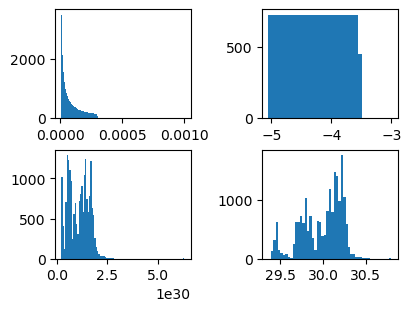

In [20]:
sed = Temple_SED
fig, axs = plt.subplots(2, 2, figsize=(4, 3), layout='constrained')
with plt.rc_context({'hist.bins': 'auto'}):
    axs[0, 0].hist(         sed.wavelength.cgs.value)
    axs[0, 1].hist(np.log10(sed.wavelength.cgs.value))
    non_zero_mask = sed.L_nu > 0
    axs[1, 0].hist(         sed.L_nu.cgs.value[non_zero_mask])
    axs[1, 1].hist(np.log10(sed.L_nu.cgs.value[non_zero_mask]))
pass

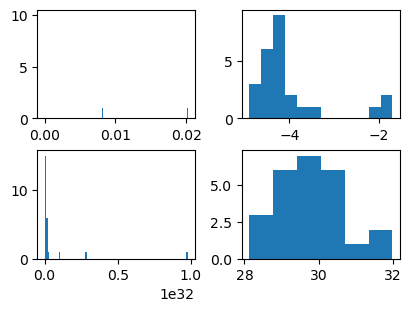

In [21]:
sed = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
fig, axs = plt.subplots(2, 2, figsize=(4, 3), layout='constrained')
with plt.rc_context(rc={'hist.bins': 'auto'}):
    axs[0, 0].hist(         sed.wavelength.cgs.value)
    axs[0, 1].hist(np.log10(sed.wavelength.cgs.value))
    non_zero_mask = sed.L_nu > 0
    lines = axs[1, 0].hist(         sed.L_nu.cgs.value[non_zero_mask])
    axs[1, 1].hist(np.log10(sed.L_nu.cgs.value[non_zero_mask]))

#### SED 的插值、积分

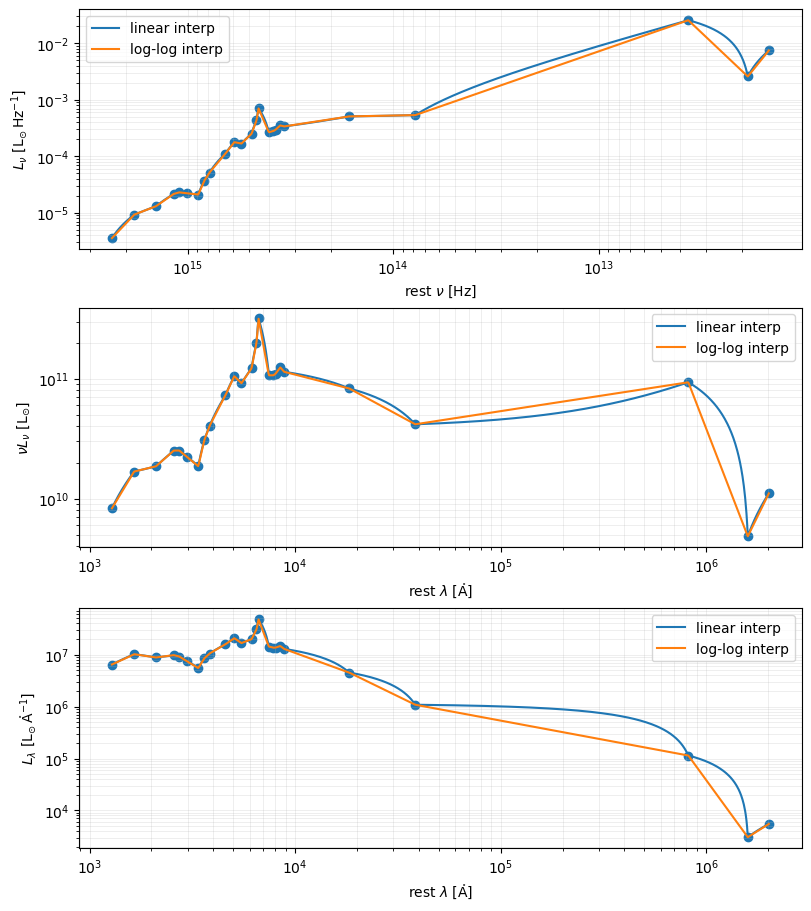

In [26]:
with u.set_enabled_equivalencies(u.spectral()):
    fig, axs = plt.subplot_mosaic([['L_nu'], ['nu_L_nu'], ['L_lambda']], figsize=(8, 9), layout='constrained')
    sed = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
    wavelength_arr = np.geomspace(min(sed.wavelength), max(sed.wavelength), 1000)

    def plot_sed(ax: plt.Axes, x, y, interp_x=None,  xlabel=None, ylabel=None, **kwargs):
        if interp_x is None:
            interp_x = x
            
        ax.scatter(x, y, )
        
        # for interp_x in [x, x.]
        ax.plot(wavelength_arr, LinearInterpolator(interp_x,y)(wavelength_arr), label='linear interp', )
        ax.plot(wavelength_arr, LogLogInterpolator(interp_x,y)(wavelength_arr), label='log-log interp', )

        ax.set_xscale('log')
        ax.set_yscale('log')
        
        ax.set_xlabel(fr'rest {xlabel} [{ax.get_xlabel()}]')
        ax.set_ylabel(fr'{ylabel} [{ax.get_ylabel()}]')
        ax.legend()
        
        ax.grid(True, which='both', linewidth=.5, alpha=.3)
        # ax.set_xlim(*[1e3, 4e4]*u.AA)
        
    plot_sed(axs['L_nu'], sed.nu, sed.L_nu, interp_x=sed.wavelength, xlabel=r'$\nu$', ylabel=r'$L_\nu$')
    axs['L_nu'].invert_xaxis()
    plot_sed(axs['nu_L_nu'], sed.wavelength, sed.nu_L_nu, xlabel=r'$\lambda$', ylabel=r'$\nu L_\nu$')
    plot_sed(axs['L_lambda'], sed.wavelength, sed.L_lambda, xlabel=r'$\lambda$', ylabel=r'$L_\lambda$')
    
    # ax.set_xlabel(fr'rest $\lambda$ [{ax.get_xlabel()}]') 
    # ax.set_ylabel(fr'$L_\nu$ [{ax.get_ylabel()}]') 
    # ax.set_aspect(.5)

测试 SED 的插值细化、采用不同的 scale 缩放下的插值对结果的影响

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_62052/534129809.py:55: RuntimeWarning: divide by zero encountered in divide
  return (h * c / k_B).to_value(u.K * u.micron) / x


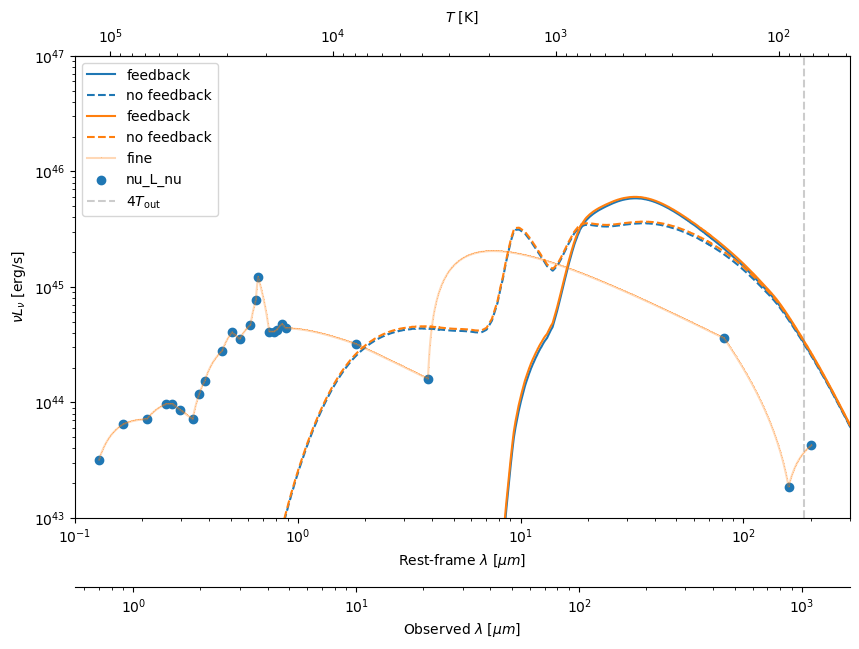

In [19]:
import copy

sed = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
sed.interpolator = LinearInterpolator
sed_fine = sed.refine(10**3)
sed.interpolator = LogLogInterpolator

model = A_V_Model(
    n_0=100 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3,
    opacity=Orion_opacity,
    observed_SED=sed,
)

model_fine = A_V_Model(
    n_0=100 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3,
    opacity=Orion_opacity,
    observed_SED=sed_fine,
)


fig, ax = plt.subplots(figsize=(10, 6))


lines = ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), label='feedback')
model.tau_ph = 0
ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), '--', label='no feedback', color=lines[0].get_color())

lines = ax.loglog(model_fine.opacity.wavelength, model_fine.calc_nu_L_nu(), label='feedback')
model_fine.tau_ph = 0
ax.loglog(model_fine.opacity.wavelength, model_fine.calc_nu_L_nu(), '--', label='no feedback', color=lines[0].get_color())
ax.plot(sed_fine.wavelength, sed_fine.nu_L_nu, ',-', label='fine', c=lines[0].get_color(), alpha=.3)

ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, )

# ax.set_yscale('linear')

# 设定坐标轴的范围
ax.set_xlim(1e-1, 3e2)
# ax.set_ylim(nu_L_nu.max() / 1e2, nu_L_nu.max() * 1e2)
ax.set_ylim(*[1e43, 1e47] * u.erg/u.s)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def wavelength_to_temperature(x):
    from astropy.constants import c, h, k_B
    return (h * c / k_B).to_value(u.K * u.micron) / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
# ax.set_title(rf"{model:latex}")

测试 trapz vs trapz_log 积分方法对结果的影响

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_62052/2891803250.py:43: RuntimeWarning: divide by zero encountered in divide
  return (h * c / k_B).to_value(u.K * u.micron) / x


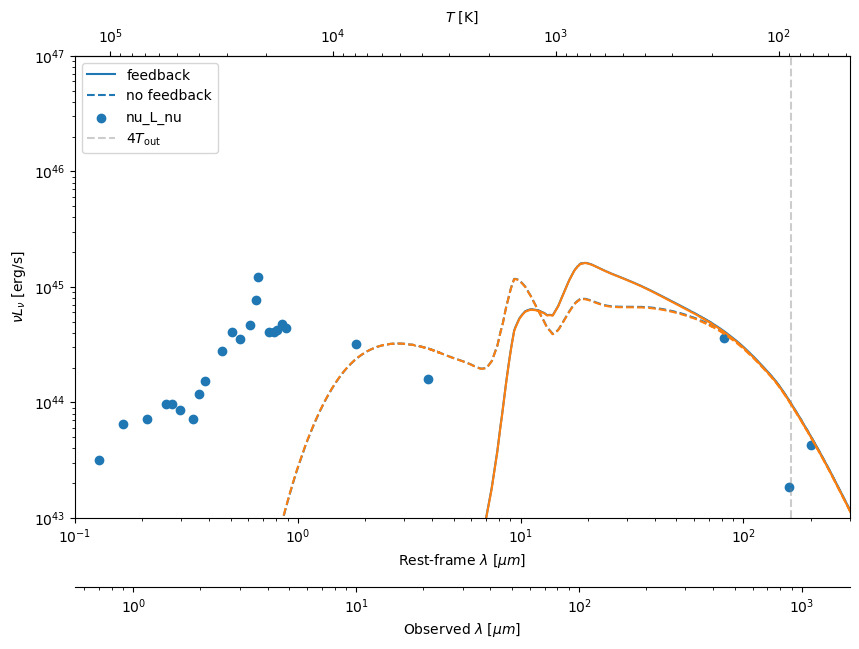

In [ ]:
import copy

fig, ax = plt.subplots(figsize=(10, 6))

sed = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])

model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.8,
    T_sub=1500 * u.K,
    A_V=2,
    opacity=Orion_opacity,
    observed_SED=sed,
    config={'r_sample_num': 50, 'r_sample_scale': 'log'}
)


nu_L_nu = model.calc_nu_L_nu()

lines = ax.loglog(model.opacity.wavelength, nu_L_nu, label='feedback')
model.tau_ph = 0
ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), '--', label='no feedback', color=lines[0].get_color())


ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, )

# ax.set_yscale('linear')

# 设定坐标轴的范围
ax.set_xlim(1e-1, 3e2)
# ax.set_ylim(nu_L_nu.max() / 1e2, nu_L_nu.max() * 1e2)
ax.set_ylim(*[1e43, 1e47] * u.erg/u.s)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def wavelength_to_temperature(x):
    from astropy.constants import c, h, k_B
    return (h * c / k_B).to_value(u.K * u.micron) / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
# ax.set_title(rf"{model:latex}")


model.config |= {
    'calc_L_nu.integrator': 'trapz',
     'IR_Flux.integrator': 'trapz',
     'UV_Flux.integrator': 'trapz',
}
model.tau_ph = 1
lines = ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), label='feedback')
model.tau_ph = 0
ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), '--', label='no feedback', color=lines[0].get_color())

### 重构继承层级

In [6]:
model = A_V_Model(n_0=1e3 * u.cm**-3, 
                  gamma=.5, 
                  T_sub=1500 * u.K, 
                  A_V=3 * u.mag(), 
                  opacity=Orion_opacity, 
                  observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
                  tau_ph=1)
# model.calc_nu_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


### r_ph 校准

In [7]:
model = A_V_Model(n_0=1e3 * u.cm**-3, 
                  gamma=.5, 
                  T_sub=1500 * u.K, 
                  A_V=3, 
                  opacity=Orion_opacity, 
                  observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']).select_wavelength_range(max=1e0*u.um,).refine(10**3),
                  tau_ph=1)
# model.calc_nu_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0, 0.5, '$\\sigma_H$')

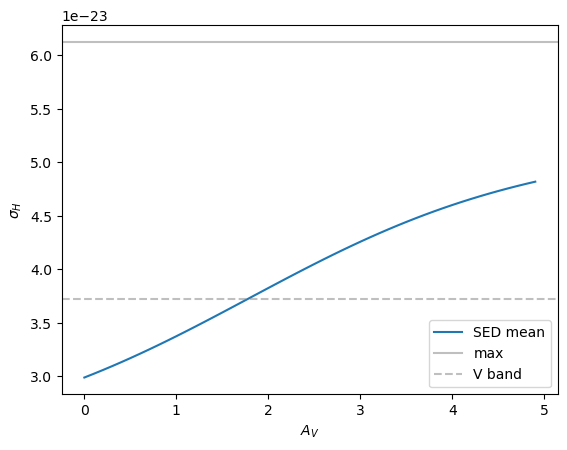

In [50]:
from LRD_IR_spectrum.OrionLRD import SED_mean_sigma_H_Prad


np.seterr(over='ignore')

A_V_list = np.arange(0, 5, .1)
sigma_list = []
for A_V in A_V_list:
    model = A_V_Model(n_0=1e3 * u.cm**-3, 
                  gamma=.5, 
                  T_sub=1500 * u.K, 
                  A_V=A_V, 
                  opacity=Orion_opacity, 
                  observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']).select_wavelength_range(max=1e0*u.um,).refine(10**3),
                  tau_ph=1)
    sigma_list.append(model.sigma_H_Prad_eff)
    
sigma_list = u.Quantity(sigma_list)


plt.plot(A_V_list, sigma_list, label='SED mean')
plt.axhline(Orion_opacity.sigma_H_Prad.max(), label='max', color='gray', ls='-', alpha=.5)
plt.axhline(Orion_opacity.sigma_H_ext_V, label='V band', color='gray', ls='--', alpha=.5)

plt.legend()
plt.xlabel(r'$A_V$')
plt.ylabel(r'$\sigma_H$')

In [11]:
u.Quantity(sigma_list)

<Quantity [2.98593589e-23, 3.16743301e-23, 3.37259010e-23, 3.59477765e-23,
           3.82388750e-23, 4.04818642e-23] cm2>

In [8]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [9]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [11]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [12]:
model.sigma_H_Prad_eff

<Quantity 4.25478577e-23 cm2>

In [13]:
op = model.opacity
op.sigma_H_ext_V, op.sigma_H_Prad.max(), op.sigma_H_ext.max()

(<Quantity 3.71876811e-23 cm2>,
 <Quantity 6.13e-23 cm2>,
 <Quantity 6.82e-23 cm2>)

In [44]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [26]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [15]:
model

正在使用 L_UV_Model 的 r_ph 方法
正在使用 L_UV_Model 的 tau_UV_profile_inverse 方法
正在使用 L_UV_Model 的 r_ph 方法
正在使用 L_UV_Model 的 tau_UV_profile_inverse 方法


/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
